<a href="https://colab.research.google.com/github/ssarinbe24-sys/AI_for_Cybersecurity-/blob/main/kMeans_Elbow_Method.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!kaggle datasets download -d boltzmannbrain/nab

Dataset URL: https://www.kaggle.com/datasets/boltzmannbrain/nab
License(s): other
100% 1.64M/1.64M [00:00<00:00, 2.92MB/s]



In [5]:
!unzip nab.zip


Archive:  nab.zip
  inflating: README.md               
  inflating: artificialNoAnomaly/artificialNoAnomaly/art_daily_no_noise.csv  
  inflating: artificialNoAnomaly/artificialNoAnomaly/art_daily_perfect_square_wave.csv  
  inflating: artificialNoAnomaly/artificialNoAnomaly/art_daily_small_noise.csv  
  inflating: artificialNoAnomaly/artificialNoAnomaly/art_flatline.csv  
  inflating: artificialNoAnomaly/artificialNoAnomaly/art_noisy.csv  
  inflating: artificialWithAnomaly/artificialWithAnomaly/art_daily_flatmiddle.csv  
  inflating: artificialWithAnomaly/artificialWithAnomaly/art_daily_jumpsdown.csv  
  inflating: artificialWithAnomaly/artificialWithAnomaly/art_daily_jumpsup.csv  
  inflating: artificialWithAnomaly/artificialWithAnomaly/art_daily_nojump.csv  
  inflating: artificialWithAnomaly/artificialWithAnomaly/art_increase_spike_density.csv  
  inflating: artificialWithAnomaly/artificialWithAnomaly/art_load_balancer_spikes.csv  
  inflating: realAWSCloudwatch/realAWSCloudwatch/

In [15]:
import pandas as pd
from sklearn.cluster import KMeans

In [7]:
temp=pd.read_csv("/content/realKnownCause/realKnownCause/ambient_temperature_system_failure.csv")

In [9]:
temp.head()

,timestamp,value
0,2013-07-04 00:00:00,69.880835
1,2013-07-04 01:00:00,71.220227
2,2013-07-04 02:00:00,70.877805
3,2013-07-04 03:00:00,68.959400
4,2013-07-04 04:00:00,69.283551


In [10]:
temp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  7267 non-null   object 
 1   value      7267 non-null   float64
dtypes: float64(1), object(1)
memory usage: 113.7+ KB


In [11]:
temp.describe()

,value
count,7267.000000
mean,71.242433
std,4.247509
min,57.458406
25%,68.369411
50%,71.858493
75%,74.430958
max,86.223213


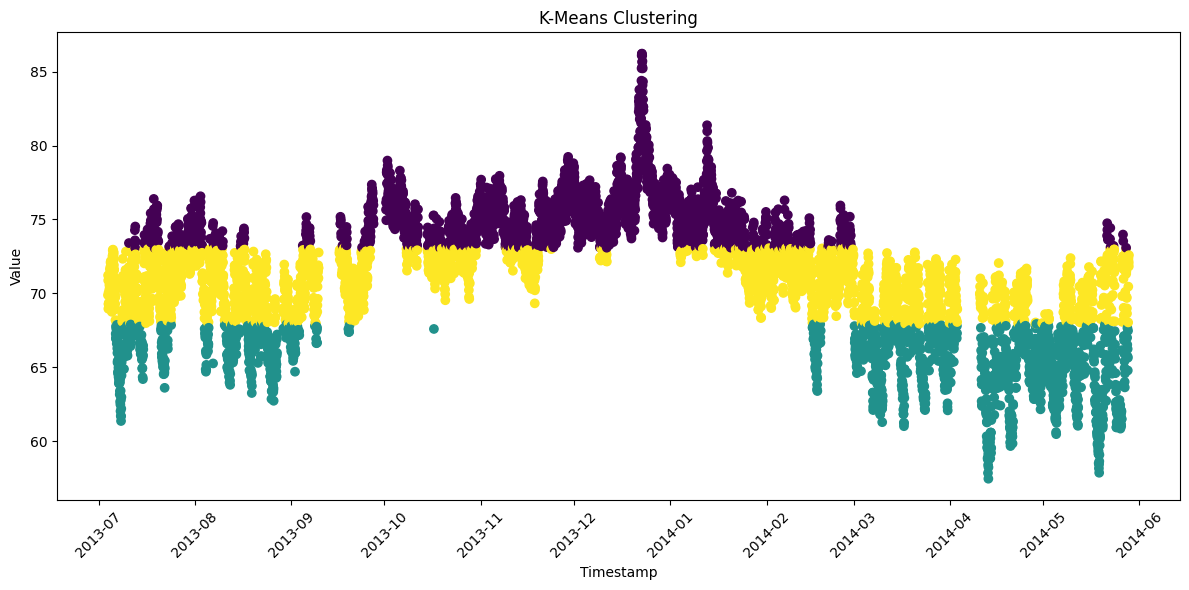

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Convert timestamp to datetime
temp['timestamp'] = pd.to_datetime(temp['timestamp'])

# Use only value for clustering
X = temp[['value']]

# Apply K-Means
kmeans = KMeans(n_clusters=3, random_state=42)

temp['Cluster'] = kmeans.fit_predict(X)

# Plot clusters
plt.figure(figsize=(12,6))
plt.scatter(temp['timestamp'], temp['value'], c=temp['Cluster'])

plt.xlabel('Timestamp')
plt.ylabel('Value')
plt.title('K-Means Clustering')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

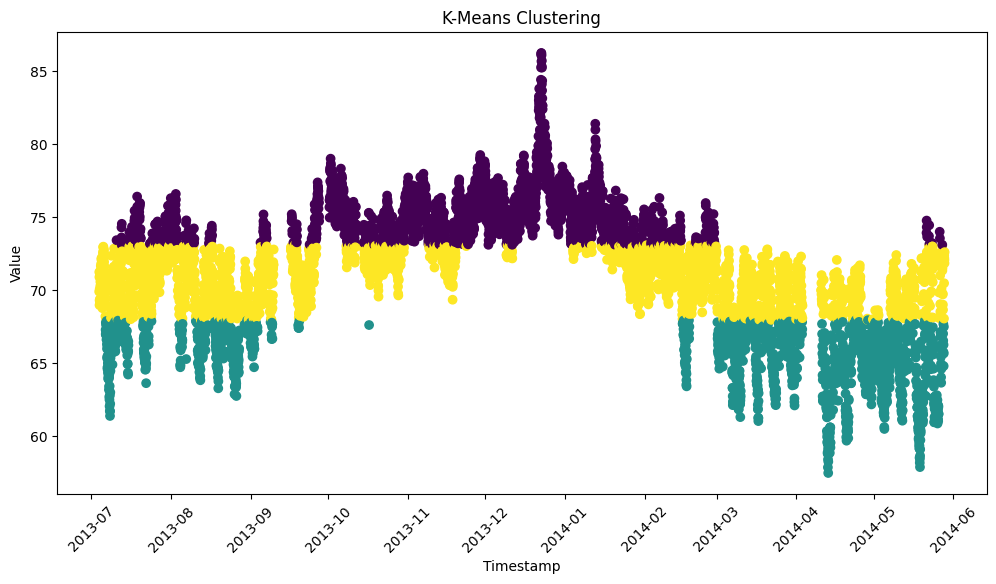

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Assuming your dataframe is named temp
X = temp[['value']]

# Apply K-Means
kmeans = KMeans(n_clusters=3, random_state=42)

temp['Cluster'] = kmeans.fit_predict(X)

# Plot
plt.figure(figsize=(12,6))
plt.scatter(temp['timestamp'], temp['value'], c=temp['Cluster'])
plt.xlabel('Timestamp')
plt.ylabel('Value')
plt.title('K-Means Clustering')
plt.xticks(rotation=45)
plt.show()

In [20]:
temp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  7267 non-null   datetime64[ns]
 1   value      7267 non-null   float64       
 2   Cluster    7267 non-null   int32         
dtypes: datetime64[ns](1), float64(1), int32(1)
memory usage: 142.1 KB


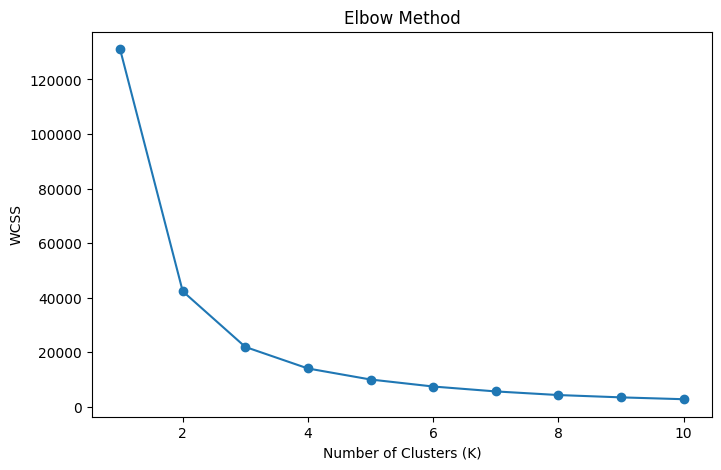

In [22]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(temp[['value']])
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()